> ### Corrected 2026-08-16 — the numbers in this notebook are superseded
>
> This notebook was executed against **2867 clips / 31 "birds"**. That count was filename
> prefixes, not individuals: `HPiHPi4748` and `HpiHpi4748` are one bird under two
> capitalizations, and four `Unknown*` prefixes (53 clips) are catch-alls. The corrected set is
> **2814 clips / 26 birds**, which moves the probe from 0.821 to **0.811** and the best k from
> 20 to **16**.
>
> Two further caveats, both detailed in `README.md`:
>
> - **No bird is held out of pretraining.** 99.5% of these clips were cut from the same 120
>   recordings the encoder was pretrained on, so "leave-birds-out" constrains the probe, not the
>   model. Read the accuracy as an upper bound for a genuinely new individual.
> - A **random split** scores 0.925 on the same features (+0.114). Check how a number was split
>   before comparing it to anything.
>
> `ZF_HuBERT_Replication.ipynb` is executed against the corrected set and reproduces it end to end.


# 1 - Quickstart: audio in, embeddings out

This notebook loads the zebra finch HuBERT encoder and embeds a few clips. It runs on a
laptop CPU in well under a minute -- no GPU, no training code, no Savio account.

**What the model is.** A HuBERT BASE encoder pretrained from scratch on ~100 hours of
unlabelled zebra finch colony recordings. It is *self-supervised*: it never saw a call-type
label during training. What it learned, it learned from predicting masked pieces of audio.

**What you get out.** For a piece of audio it returns 12 embeddings -- one per transformer
layer -- each a 768-dimensional vector per 20 ms frame. Different layers are good at
different things, which is the point of notebook 2.

In [1]:
import sys, os
sys.path.insert(0, "..")          # so `import zf_hubert` finds the module one level up
import numpy as np
import matplotlib.pyplot as plt
from zf_hubert import load_encoder, load_audio, embed_file, embed_frames, LAYER_NOTES

model = load_encoder("../weights/zf_hubert_run11_encoder.pt")   # ~360 MB, CPU is fine
meta  = model.zf_meta
print(meta["description"])
print()
print(f"pretraining : {meta['training']['objective']}, {meta['training']['steps']:,} steps")
print(f"audio       : {meta['sample_rate']} Hz mono")
print(f"outputs     : {meta['n_layers']} layers x {meta['embed_dim']} dims, "
      f"one frame per {meta['frame_stride_ms']} ms")

HuBERT BASE pretrained from scratch on ~100 h of unlabelled zebra finch colony audio (self-supervised, no call-type labels ever seen during pretraining).

pretraining : HuBERT masked-prediction, iteration 1, 93,750 steps
audio       : 16000 Hz mono
outputs     : 12 layers x 768 dims, one frame per 20 ms


## Embed a single clip

`embed_file` mean-pools over time, giving one 768-d vector per layer. That is what every
number in the README was computed from.

In [2]:
wav_path = "../examples/BlaBla0506_110302-DC-01.wav"    # DC = distance call

emb = embed_file(model, wav_path)
print("mean-pooled :", emb.shape, "  (layer, dim)")

frames = embed_frames(model, load_audio(wav_path))
print("frame-level :", frames.shape, "  (layer, time, dim)")

dur = load_audio(wav_path).shape[1] / 16000
print(f"\nclip is {dur:.2f} s -> {frames.shape[1]} frames at 20 ms each")

mean-pooled : (12, 768)   (layer, dim)
frame-level : (12, 11, 768)   (layer, time, dim)

clip is 0.24 s -> 11 frames at 20 ms each


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


## What the layers actually look like

Spectrogram on top, then the frame-level activations of a shallow and a deep layer. You are
looking for whether the embedding "lights up" where the call is. Layer 0 tracks the acoustics
closely; deeper layers are smoother and more abstract.

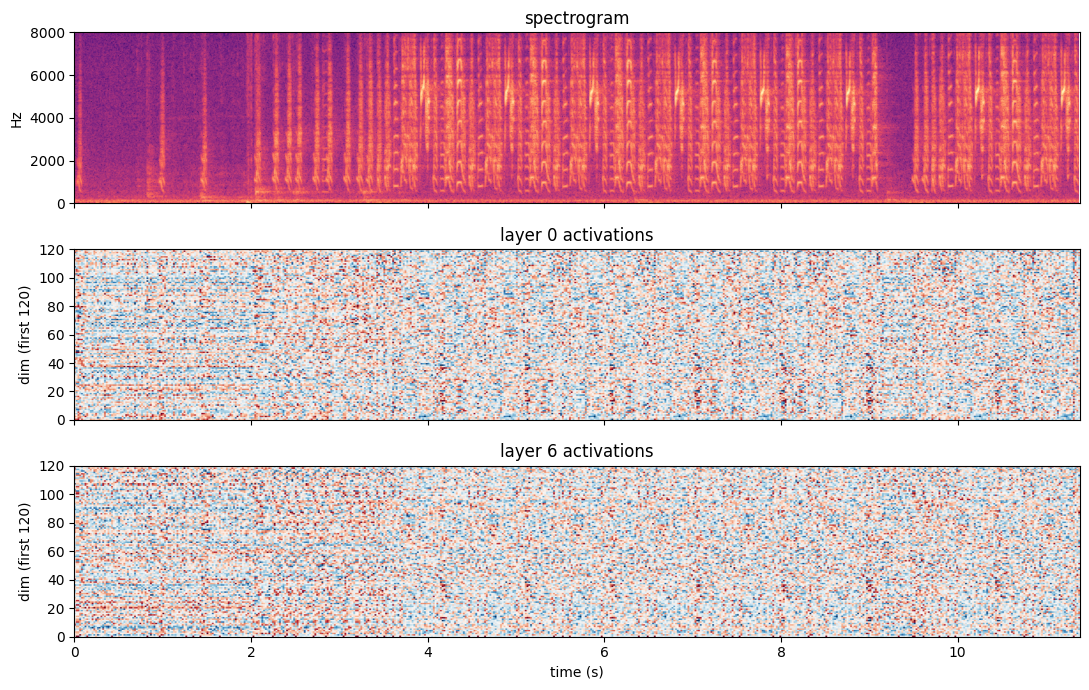

In [3]:
wav = load_audio("../examples/BlaBla0506_110304-Song-06.wav")   # song, longer clip
frames = embed_frames(model, wav)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].specgram(wav.numpy()[0], NFFT=512, Fs=16000, noverlap=384, cmap="magma")
axes[0].set_ylabel("Hz"); axes[0].set_title("spectrogram")

for ax, L in zip(axes[1:], [0, 6]):
    a = frames[L]                                  # (T, 768)
    a = (a - a.mean(0)) / (a.std(0) + 1e-8)        # z-score per dim, else a few dims dominate
    t = np.linspace(0, wav.shape[1] / 16000, a.shape[0])
    ax.imshow(a[:, :120].T, aspect="auto", origin="lower", cmap="RdBu_r",
              vmin=-3, vmax=3, extent=[t[0], t[-1], 0, 120])
    ax.set_ylabel("dim (first 120)"); ax.set_title(f"layer {L} activations")
axes[-1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

## Do clips of the same call type look alike?

16 example clips, two per call type. Cosine similarity between mean-pooled layer-3 embeddings,
ordered by call type. If the model encodes call type at all, the 2x2 blocks on the diagonal
should be brighter than everything else.

This is a 16-clip eyeball test, not evidence -- notebook 2 does it properly with a probe and
notebook 3 without labels at all.

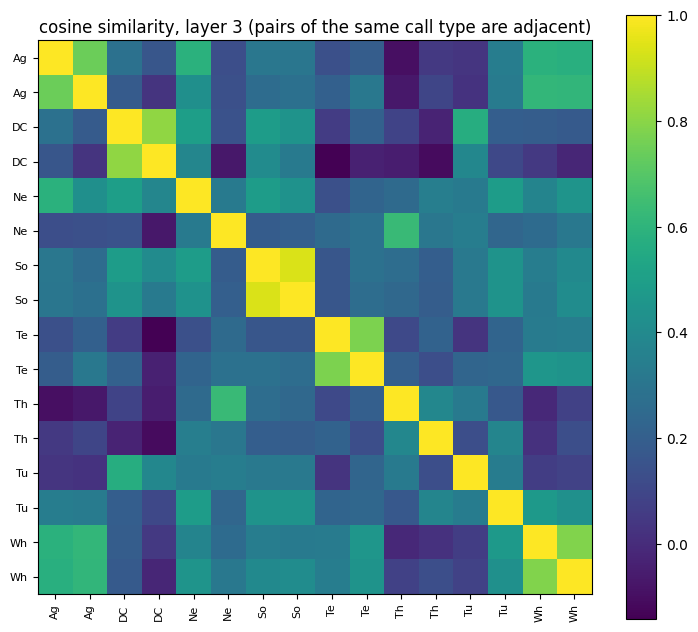

In [4]:
import glob, csv
# Use the shipped ground-truth labels rather than parsing filenames -- the filename convention
# is not quite one-to-one with the 8 class codes.
truth = {r["fname"]: r["label"] for r in csv.DictReader(open("../data/calltype_labels.csv"))}
paths  = sorted(glob.glob("../examples/*.wav"), key=lambda p: truth[os.path.basename(p)])
labels = [truth[os.path.basename(p)] for p in paths]

E = np.stack([embed_file(model, p, layer=3) for p in paths])
E = E / np.linalg.norm(E, axis=1, keepdims=True)
S = E @ E.T

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(S, cmap="viridis")
ax.set_xticks(range(len(paths))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(paths))); ax.set_yticklabels(labels, fontsize=8)
ax.set_title("cosine similarity, layer 3 (pairs of the same call type are adjacent)")
plt.colorbar(im); plt.tight_layout(); plt.show()

## Which layer should you use?

In [5]:
print(LAYER_NOTES)

Which layer to use (measured on this corpus -- see README for the full tables):

  layer 0   vocalization vs. background detection. AUC 0.921, and it declines monotonically
            with depth (0.883 by layer 11). Shallow layers keep the acoustic detail that
            separates "sound happened" from "silence".

  layer 3   8-way call-type classification. Accuracy 0.821 leave-birds-out. But the profile is
            nearly flat across all 12 layers (0.797-0.821), so layer 3 is a weak peak, not a
            sharp optimum. Any of layers 0-5 will perform about the same.

  all 12    If you are doing something new, extract everything (it costs one forward pass) and
            sweep. That is how both numbers above were found.



### Embedding your own audio

```python
from zf_hubert import load_encoder, embed_file, embed_files

model = load_encoder("weights/zf_hubert_run11_encoder.pt", device="cuda")  # or "cpu"

emb = embed_file(model, "my_clip.wav")            # (12, 768) - all layers
emb = embed_file(model, "my_clip.wav", layer=0)   # (768,)    - just layer 0

X = embed_files(model, list_of_paths, layer=3)    # (n_clips, 768)
```

Any sample rate and any number of channels works -- audio is resampled to 16 kHz and
downmixed to mono automatically. Clips shorter than ~0.05 s will fail: the conv feature
extractor needs a minimum receptive field.